# 합성곱 신경망을 사용한 이미지 분류


## Exp 13 - EarlyStopping Patience 4

- 변경 내용: Baseline 구조는 유지하고 EarlyStopping patience를 2에서 4로 변경한다.
- 실험 목적: validation loss가 일시적으로 흔들릴 때 더 오래 기다리는 학습 전략이 성능에 미치는 영향을 확인한다.
- 비교 기준: 동일한 데이터 분할, 동일한 seed, 동일한 최대 epoch 조건을 사용한다.
- 실험 근거: patience를 늘리면 학습 기회를 더 주지만 학습 시간이 늘어날 수 있으므로, Baseline의 patience=2와 비교한다.



In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/08-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>


In [2]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()


## 패션 MNIST 데이터 불러오기


In [3]:
import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 합성곱 신경망 만들기


In [4]:
model = keras.Sequential(name='exp13_earlystop_patience4')
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))



In [5]:
model.summary()


Model: "exp13_earlystop_patience4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

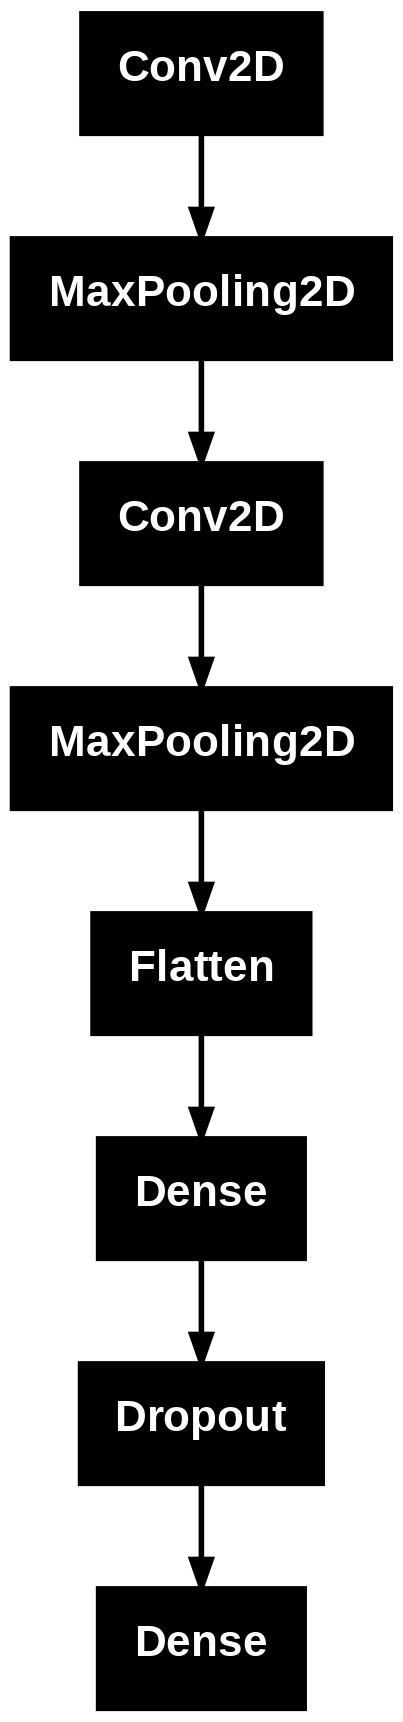

In [6]:
keras.utils.plot_model(model)


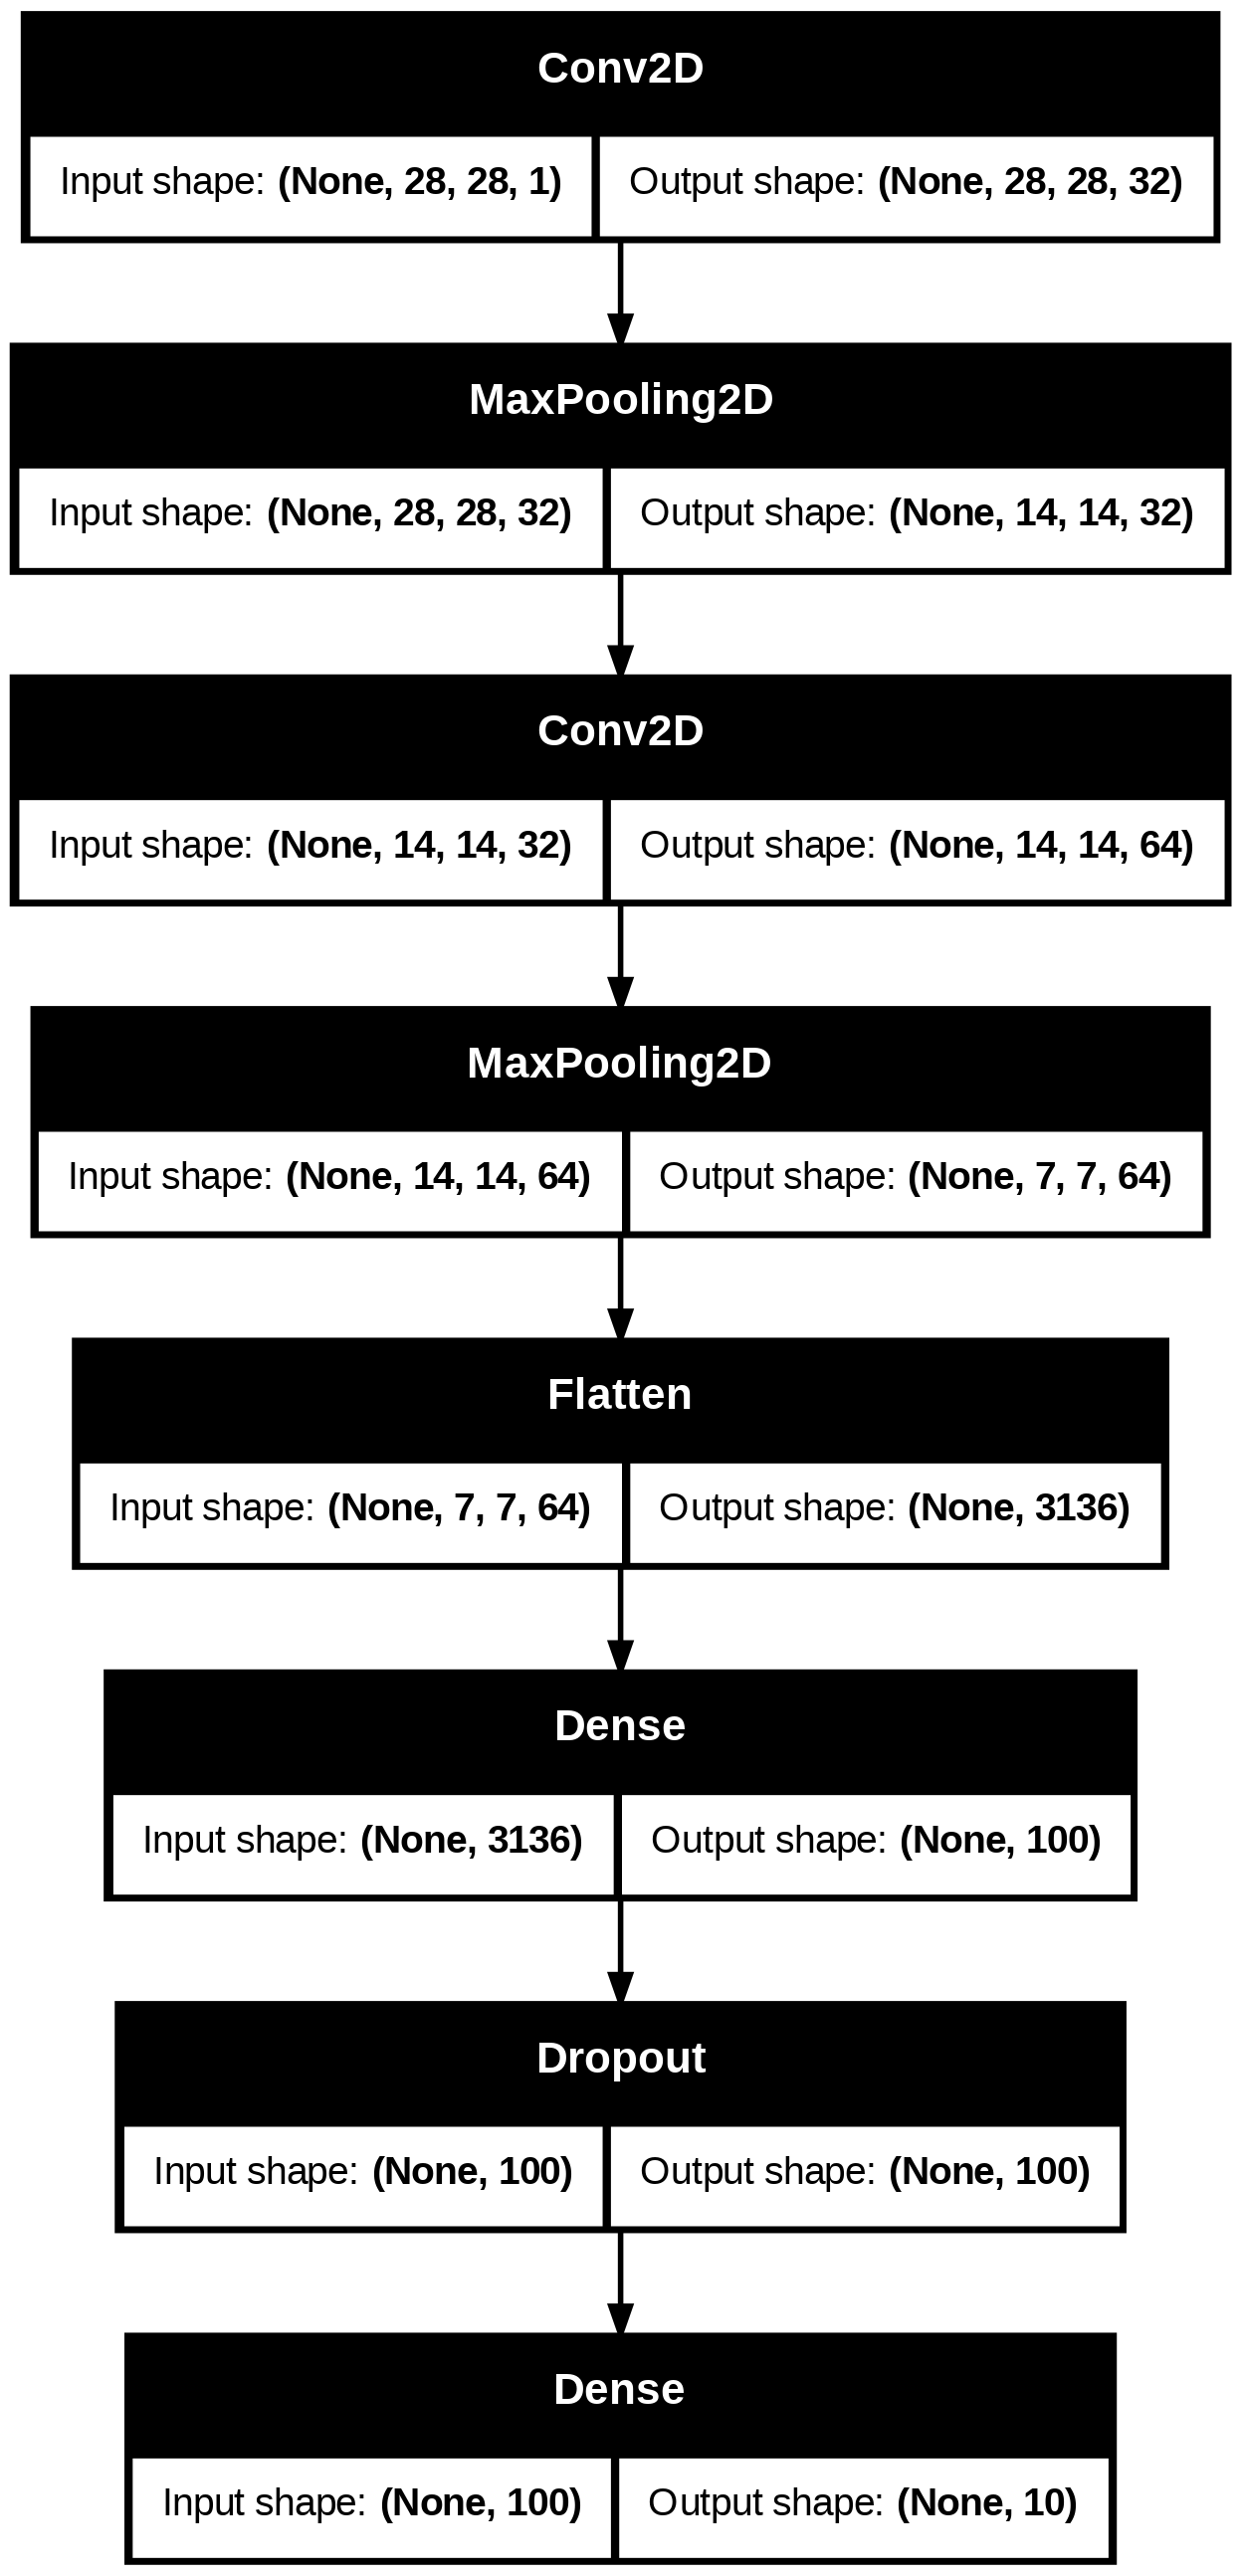

In [7]:
keras.utils.plot_model(model, show_shapes=True)


## 모델 컴파일과 훈련


In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              # 현재 텐서플로 버전에서는 최대 풀링에 대한 결정적인 XLA 구현이 없기 때문에
              # enable_op_determinism() 호출로 인해 오류가 발생합니다.
              # 이를 피하기 위해 jit_compile 옵션을 False로 지정합니다.
              # https://github.com/tensorflow/tensorflow/issues/69417
              jit_compile=False)
checkpoint_cb = keras.callbacks.ModelCheckpoint('13_earlystop_patience4.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=4,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=15,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])




Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.8105 - loss: 0.5285 - val_accuracy: 0.8797 - val_loss: 0.3276
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - accuracy: 0.8756 - loss: 0.3481 - val_accuracy: 0.8993 - val_loss: 0.2746
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8919 - loss: 0.2977 - val_accuracy: 0.9018 - val_loss: 0.2552
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9043 - loss: 0.2651 - val_accuracy: 0.9093 - val_loss: 0.2459
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9124 - loss: 0.2419 - val_accuracy: 0.9132 - val_loss: 0.2340
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9187 - loss: 0.2213 - val_accuracy: 0.9160 - val_loss: 0.2284
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9242 - loss: 0.2038 - val_accuracy: 0.9191 - val_loss: 0.2255
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9306 -

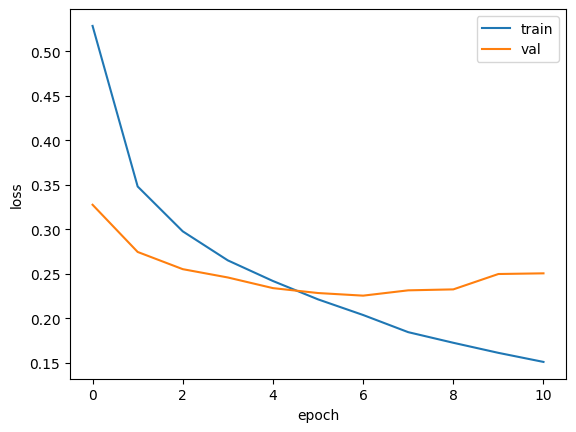

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()


## Accuracy Curve

Train accuracy와 validation accuracy를 비교하여 일반화 성능과 과적합 여부를 확인합니다.



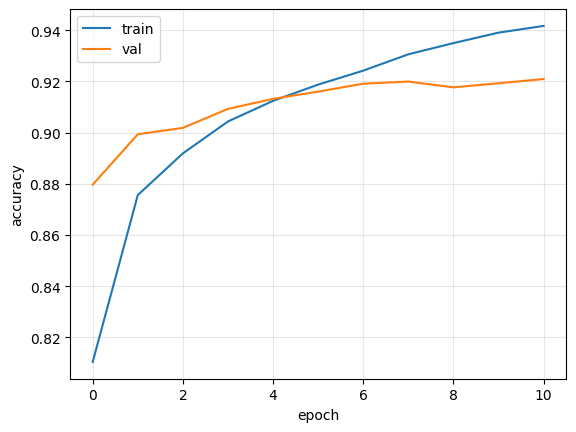

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'val'])
plt.grid(True, alpha=0.3)
plt.show()




In [11]:
model.evaluate(val_scaled, val_target)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9191 - loss: 0.2255


[0.225491002202034, 0.9190833568572998]

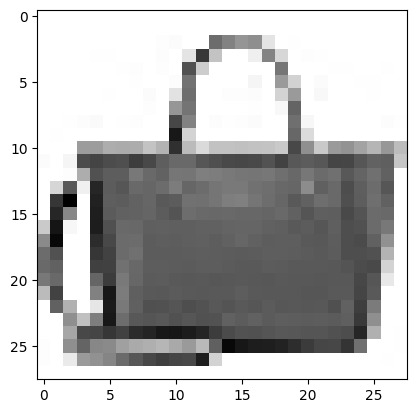

In [12]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()


In [13]:
preds = model.predict(val_scaled[0:1])
print(preds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
[[2.2989703e-17 2.2168874e-23 1.9206553e-18 2.3270205e-16 1.6824198e-15
  4.0414136e-16 1.9692811e-17 2.6914546e-15 1.0000000e+00 1.2395960e-17]]


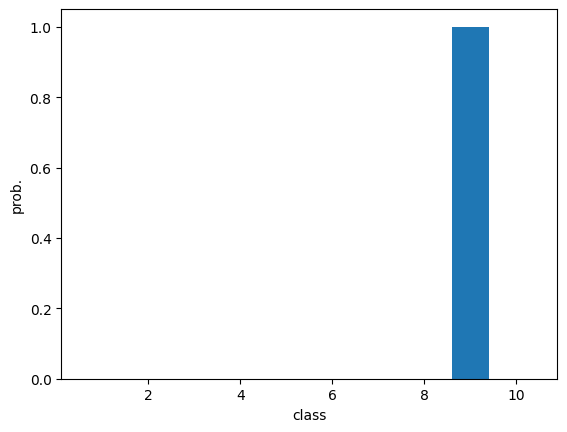

In [14]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()


In [15]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']


In [16]:
import numpy as np

print(classes[np.argmax(preds)])


가방


In [17]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0


In [18]:
model.evaluate(test_scaled, test_target)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9160 - loss: 0.2488


[0.2488059252500534, 0.9160000085830688]

## Confusion Matrix

Test set에서 어떤 class끼리 혼동되는지 확인합니다.



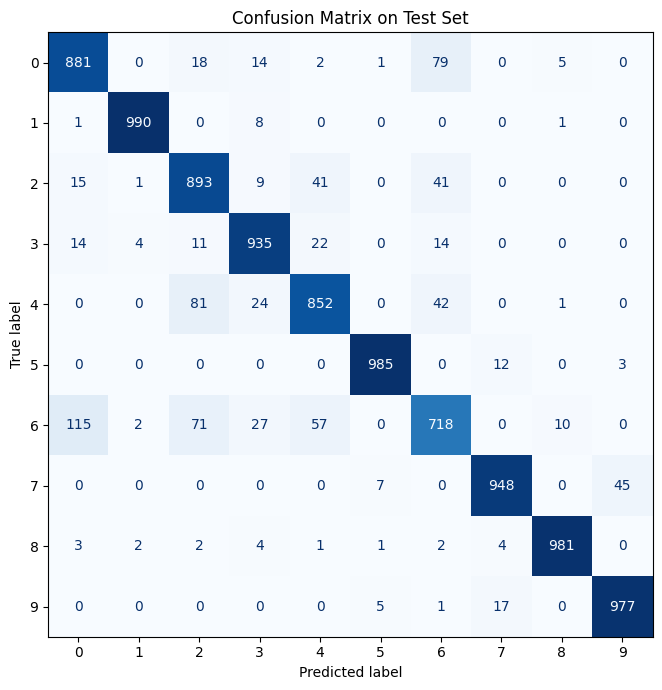

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

pred_labels = model.predict(test_scaled, verbose=0).argmax(axis=1)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    test_target,
    pred_labels,
    display_labels=range(10),
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()




## 실험 결과 저장

집계 노트북에서 비교할 수 있도록 validation/test 성능과 loss history를 JSON 파일로 저장합니다.



In [20]:
import json
import os

val_loss, val_accuracy = model.evaluate(val_scaled, val_target, verbose=0)
test_loss, test_accuracy = model.evaluate(test_scaled, test_target, verbose=0)

try:
    RESULT_DIR = '/content/drive/MyDrive/CNN_fashion_results'
    os.makedirs(RESULT_DIR, exist_ok=True)
except Exception:
    RESULT_DIR = './CNN_fashion_results'
    os.makedirs(RESULT_DIR, exist_ok=True)

result = {
    'experiment_name': model.name,
    'parameter_count': int(model.count_params()),
    'epochs_ran': len(history.history['loss']),
    'best_val_loss': float(min(history.history['val_loss'])),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'final_val_loss': float(val_loss),
    'final_val_accuracy': float(val_accuracy),
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'train_loss_history': [float(x) for x in history.history['loss']],
    'val_loss_history': [float(x) for x in history.history['val_loss']],
    'train_accuracy_history': [float(x) for x in history.history['accuracy']],
    'val_accuracy_history': [float(x) for x in history.history['val_accuracy']],
}

result_path = os.path.join(RESULT_DIR, f'{model.name}.json')
with open(result_path, 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print('Saved result:', result_path)
print(result)




Saved result: /content/drive/MyDrive/CNN_fashion_results/exp13_earlystop_patience4.json
{'experiment_name': 'exp13_earlystop_patience4', 'parameter_count': 333526, 'epochs_ran': 11, 'best_val_loss': 0.225491002202034, 'best_val_accuracy': 0.9209166765213013, 'final_val_loss': 0.225491002202034, 'final_val_accuracy': 0.9190833568572998, 'test_loss': 0.2488059252500534, 'test_accuracy': 0.9160000085830688, 'train_loss_history': [0.5285184979438782, 0.3481144309043884, 0.29773226380348206, 0.26509949564933777, 0.2419424057006836, 0.22131448984146118, 0.20375056564807892, 0.18447162210941315, 0.1725434958934784, 0.16122128069400787, 0.15103371441364288], 'val_loss_history': [0.32759442925453186, 0.2745782732963562, 0.25524771213531494, 0.2459007352590561, 0.233951136469841, 0.22842876613140106, 0.225491002202034, 0.23145461082458496, 0.23252616822719574, 0.2498028427362442, 0.2505546808242798], 'train_accuracy_history': [0.8104583621025085, 0.8756041526794434, 0.8918750286102295, 0.9043333